In [50]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tools.eval_measures import rmse, mse, meanabs
from statsmodels.graphics.tsaplots import month_plot, quarter_plot

In [22]:
# The data is non-stationary if it has a trend or a seasonality (or both), 
# which means that the mean and variance of the data change over time.

In [27]:
df1 = pd.read_csv("../data/airline_passengers.csv", index_col="Month", parse_dates=True)
df1.index.freq = "MS"

df2 = pd.read_csv("../data/DailyTotalFemaleBirths.csv", index_col="Date", parse_dates=True)
df2.index.freq = "D"

df3 = pd.read_csv("../data/samples.csv", index_col=0, parse_dates=True)
df3.index.freq = "MS"

In [ ]:
# Augmented Dickey-Fuller test for df1

# if the ADF Test Statistic < Critical Value (1% significance level), 
# we reject the null hypothesis and conclude that the series is stationary at the 1% level
# p-value < 0.01 also indicates that we can reject the null hypothesis at the 1% significance level

dftest = adfuller(df1["Thousands of Passengers"])
dfout = pd.Series(dftest[0:4], index=["ADF Test Statistic", "p-value", "Lags Used", "Observations Used"])
for key, value in dftest[4].items():
    dfout[f"Critical Value ({key})"] = value
dfout

ADF Test Statistic        0.815369
p-value                   0.991880
Lags Used                13.000000
Observations Used       130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
dtype: float64

In [24]:
# another way of doing the ADF with a function
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    dftest = adfuller(series.dropna(), autolag='AIC')
    dfout = pd.Series(dftest[0:4], index=['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfout[f'Critical Value ({key})'] = value

    print(dfout.to_string())
    print("\nNull Hypothesis: The series is non-stationary.")
    if dftest[1] <=0.05:
        print("Strong evidence against the null hypothesis, \nreject the null hypothesis. \nThe series is stationary.")
    else:
        print("Weak evidence against the null hypothesis, \nfail to reject the null hypothesis. \nThe series is non-stationary.")

In [25]:
adf_test(df1["Thousands of Passengers"])

Augmented Dickey-Fuller Test: 
ADF Test Statistic               0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770

Null Hypothesis: The series is non-stationary.
Weak evidence against the null hypothesis, 
fail to reject the null hypothesis. 
The series is non-stationary.


In [26]:
adf_test(df2["Births"])

Augmented Dickey-Fuller Test: 
ADF Test Statistic              -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089

Null Hypothesis: The series is non-stationary.
Strong evidence against the null hypothesis, 
reject the null hypothesis. 
The series is stationary.


<Axes: >

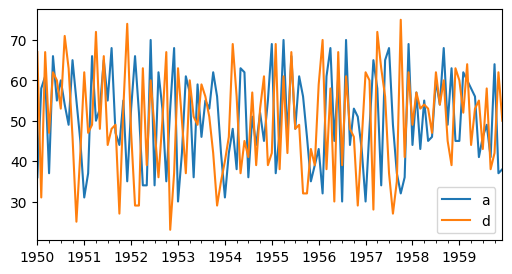

In [32]:
df3[["a", "d"]].plot(figsize=(6, 3))

<Axes: >

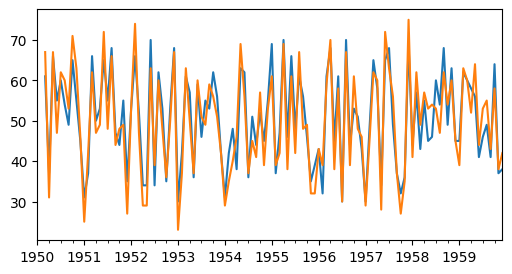

In [39]:
# we can see that there is a causal relationship between the two series

df3["a"].iloc[2:].plot(figsize=(6, 3))
df3["d"].shift(2).plot() # as this occurs first, we lag the series by 2 periods

In [ ]:
# the more maxlags we use, the more lags we test for causality, 
# but it also increases the computational cost and the risk of overfitting.
grangercausalitytests(df3[["a", "d"]], maxlag=5);

# we can see in the data that p-values start to become 0 at lag 2, 
# which means that there is a significant causal relationship between the two series at lag 2.
# The F test is the highest at lag 2, which means that the model with lag 2 has the best fit to the data.
# F test is a measure of how well the model fits the data, and a higher F test indicates a better fit.


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.7492  , p=0.1860  , df=1
likelihood ratio test: chi2=1.7365  , p=0.1876  , df=1
parameter F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=597.3806, p=0.0000  , df=2
likelihood ratio test: chi2=212.6514, p=0.0000  , df=2
parameter F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=188.7446, p=0.0000  , df_denom=110, df_num=3
ssr based chi2 test:   chi2=602.2669, p=0.0000  , df=3
likelihood ratio test: chi2=212.4789, p=0.0000  , df=3
parameter F test:         F=188.7446, p=0.0000  , df_denom=110, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=136.1258, p=0.0000  

In [41]:
# in this case we can observe that there is no causal relationship between the two series, 
# as the p-values are not significant at any lag.
grangercausalitytests(df3[["b", "d"]], maxlag=5);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5225  , p=0.2197  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.5619  , p=0.2114  , df=1
likelihood ratio test: chi2=1.5517  , p=0.2129  , df=1
parameter F test:         F=1.5225  , p=0.2197  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4350  , p=0.6483  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=0.9086  , p=0.6349  , df=2
likelihood ratio test: chi2=0.9051  , p=0.6360  , df=2
parameter F test:         F=0.4350  , p=0.6483  , df_denom=113, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5333  , p=0.6604  , df_denom=110, df_num=3
ssr based chi2 test:   chi2=1.7018  , p=0.6365  , df=3
likelihood ratio test: chi2=1.6895  , p=0.6393  , df=3
parameter F test:         F=0.5333  , p=0.6604  , df_denom=110, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.7084  , p=0.5879  

In [47]:
df = pd.read_csv("../data/airline_passengers.csv", index_col="Month", parse_dates=True)
df.index.freq = "MS"

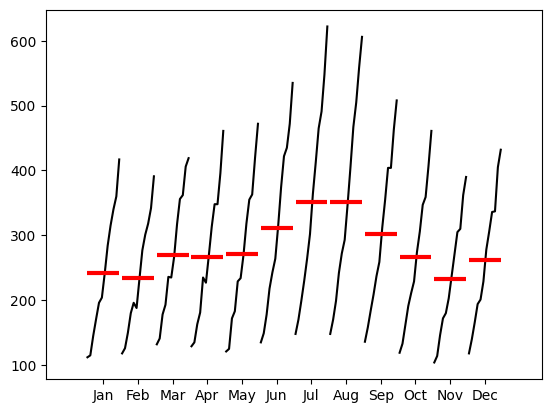

In [53]:
# the month plot is a useful tool for visualizing the seasonality of a time series,
# as it shows the average value of the series for each month of the year.
# it is essentially a groupby operation
month_plot(df["Thousands of Passengers"]);

# we can observe that there is a clear seasonality in the data, with peaks in the summer months 
# and troughs in the winter months, but in december there is a peak again (Christmas season)

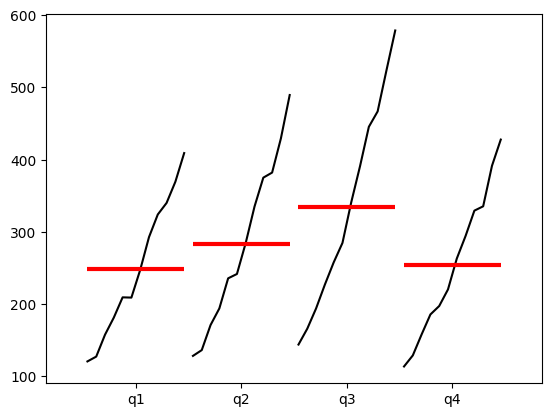

In [ ]:
dfq = df["Thousands of Passengers"].resample("QS").mean()
quarter_plot(dfq);
# we can see an increase in the 3rd quarter, which is the summer season, 
# and a decrease in the 1st and 4th quarter